# Jupyter - Day 10 - Section 001
# Lec 10: Logistic Regression

In [25]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
%matplotlib inline
import seaborn as sns

# Getting a feel for the data

We're going to use the `Default` data set from the ISLR book as included in their R package.  I've included a csv on the [DataSets page](../../DataSets/DataSets.md) for you to use. 

In [26]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/0bf0b0b65f603971cd33a04ad934449c/Default.csv"
Default = pd.read_csv(url)
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [27]:
# Here's all the entries in the "default" column
list(Default['default'].unique())

['No', 'Yes']

## Classification using Logistic Regression

Our goal is to predict `default`, a categorical variable taking as values the strings `No` and `Yes`.


For this module, we will largely use the tools from `sklearn`  for classification. One of the big perks of the `sklearn` module is that there is a great deal of uniformity in the classes. So once we have a handle on how to interact with one kind of classification tool, very minor tweaks in the code will allow for the use of a new model. In fact, many of the things we'll do today should look very similar in terms of the syntax to the linear regression lab from a few weeks ago. 

For our first try doing classification, we'll use `LogisticRegression` from the `sklearn.linear_model` module. I'm a huge fan of the `sklean` documentaiton since it includes a great deal of info on the math behind what we're doing as well as explanations on the code:
- [`sklearn` mathematical description of logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [`LogisticRegression` class documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)

In [28]:
from sklearn.linear_model import LogisticRegression 

Lets first predict `default` using `balance`. 
Our first job is to extract the portion of the dataframe that we want to use. 

In [29]:
X = Default[['balance']] 
Y = Default['default']

In [30]:
print(X.shape)
print(Y.shape)

(10000, 1)
(10000,)


Once we have our data, we create an instance of the model class we want, in this case `LogisticRegression`, and fit the model to the data. Note the `random_state=0` code ensures that rerunning the following box will return the same answer every time. 

In [31]:
clf = LogisticRegression(random_state=0)
clf.fit(X,Y)


LogisticRegression(random_state=0)

One thing that is helpful for later is the `.classes_` variable which stores the possible values of $Y$ being predicted. Take note of the order of these things, it will matter later!

In [32]:
clf.classes_

array(['No', 'Yes'], dtype=object)

Great, that was easy! Once we've fit the model, the main task is to understand how to extract information from it. 

&#9989; **<font color=red>Do this:</font>** Extract the coefficients and intercept from the trained model.  
- What is the equation, in terms of the variables used, that you are modeling?


*(Hint: You might need to take a look at the documentation to figure out how get the coefficients and intercepts, but you should notice that `sklearn` has a pattern as to how it does this.)*

In [10]:
# Your code here

&#9989; **<font color=red>Do this:</font>** Extract the coefficients and intercept from the trained model.  
- Be specific about what probability you are modeling! 

In [34]:
###YOUR ANSWER HERE###

While it's good to know what equation we're modeling with, the big perk here is that your `sklearn` class will evaluate the data points of your model for you. Yay!

&#9989; **<font color=red>Do this:</font>** Use the `predict_proba` function to determine the probabilities $Pr(Y = \texttt{Down} \mid X)$ for the data set. What shape is the output matrix? Why that shape? What do the columns represent?

In [17]:
# Checking up on the order of classes 

clf.classes_

array(['No', 'Yes'], dtype=object)

In [12]:
# Your code here

Of course this gives us the probability of each each label for a given data, but we really would like to have the prediction itself. 


&#9989; **<font color=red>Do this:</font>** (a). Use the `predict` function to determine the predictions for each input data point in the original $X$ matrix and store the output as `Yhat`. How many predictions are different than the actual `Direction` value? Whats the percent error for the model?

In [16]:
# Your code here


&#9989; **<font color=red>Do this:</font>** (b). How many predictions are different than the actual `Direction` value? Whats the percent error for the model?

In [ ]:
###YOUR ANSWER HERE###


&#9989; **<font color=red>Do this:</font>** An even easier way of figuring out the error rate is through the score. What does the output of `clf.score(X,Y)` mean and how is it related to the number you determined above?

In [25]:
# Your code here

**Confusion matrix**

As we saw in class, the percent error is a rather limited way of evaluating the classification model. Luckily `sklearn` provides commands for computing the confusion matrix for a given model easily. The `confusion_matrix` command computes the confusion matrix, and `ConfusionMatrixDisplay` gives a nice visual representation. 

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [21]:
# This code gives the confusion matrix, assuming you stored the predicted values as `Yhat`.
C = confusion_matrix(Y,Yhat)

C

array([[9625,   42],
       [ 233,  100]])

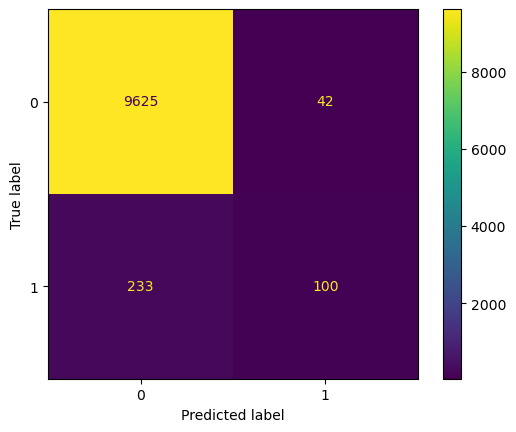

In [22]:
# This code gives a visual representation 
ConfusionMatrixDisplay(C).plot()



&#9989; **<font color=red>Q:</font>** The makers of `sklearn` made a strange choice when it comes to the confusion matrix representation.  What is different about the `sklearn` confusion matrix from how we saw it in class?

*Your answer here*



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.